# 05 - Vector Similarity Retrieval, Chunk-Level (ContraDoc)

Under the GraphRAG schema from step 03, candidate contradiction pairs are **chunk pairs**. Each `:Chunk` carries its sentence text and a pre-computed SBERT embedding. This notebook retrieves per-document top-K chunk pairs by cosine similarity and reports gold-pair recall alongside the structural baselines from step 04.

## Retrieval

For each document, every intra-doc chunk pair is scored by cosine similarity on the chunk embeddings, and the K highest-scoring pairs are kept. Pair count scales as `K × #docs` exactly (e.g., K=10 -> 1,500 pairs across 150 docs).

The structural baselines (S-SR / S-SO / S-Union) are unchanged from step 04: same queries with the MinIE-aware disjuncts. S-SR catches *different object OR same object with different `quantity`*; S-SO catches *different predicate OR same predicate with flipped `polarity`*. Both disjuncts recover signal that MinIE-style normalization moved out of the predicate / object strings.

**Output:** `data/processed/ContraDoc/chunk_candidates.jsonl` - one JSON object per candidate chunk pair at the chosen K (unioned with S-Union), consumed by notebook 06 (NLI).

In [1]:
import json
from collections import defaultdict
from pathlib import Path

import numpy as np
from neo4j import GraphDatabase

from config import settings

OUTPUT_PATH = Path("data/processed/ContraDoc/chunk_candidates.jsonl")
K_VALUES = [1, 3, 5, 10, 20]
PRIMARY_K = 20

## Connect and pull chunks from Neo4j

Each `:Chunk` node carries the sentence text and its pre-computed embedding from step 03.

In [2]:
driver = GraphDatabase.driver(
    settings.neo4j_uri,
    auth=(settings.neo4j_user, settings.neo4j_password.get_secret_value()),
)
driver.verify_connectivity()


def run(cypher, **params):
    with driver.session() as s:
        return list(s.run(cypher, **params))


chunk_rows = run(
    "MATCH (c:Chunk) "
    "RETURN c.doc_id AS doc_id, c.sentence_id AS sid, c.source_text AS text, c.embedding AS embedding, "
    "       c.is_gold_evidence AS is_gold_evidence, c.is_gold_ref AS is_gold_ref, c.ref_index AS ref_index"
)
chunks = [dict(r) for r in chunk_rows]
print(f"Loaded {len(chunks)} chunks from Neo4j.")

doc_label = {r["d"]: r["l"] for r in run("MATCH (d:Document) RETURN d.doc_id AS d, d.contradiction AS l")}
print(f"YES docs: {sum(1 for v in doc_label.values() if v == 'YES')}, NO docs: {sum(1 for v in doc_label.values() if v == 'NO')}")

Loaded 5651 chunks from Neo4j.
YES docs: 150, NO docs: 0


## Chunk keys, gold pairs, and the pkey helper

A chunk is identified by `(doc_id, sentence_id)`. A chunk pair is an unordered tuple of two such keys.

In [ ]:
def chunk_key(c):
    return (c["doc_id"], c["sid"])


def pkey(a, b):
    return (a, b) if a < b else (b, a)


# Build per-doc chunk lists + index arrays for the embedding matrix
chunks_by_doc = defaultdict(list)
for i, c in enumerate(chunks):
    chunks_by_doc[c["doc_id"]].append(i)

# Stack embeddings into a matrix
embeddings = np.asarray([c["embedding"] for c in chunks], dtype=np.float32)
print(f"Embedding matrix shape: {embeddings.shape}")

# Cross-chunk gold pairs only: exclude same-sentence (ev_sid == ref_sid) pairs,
# since chunk-level retrieval cannot return a chunk paired with itself.
gold_pairs = set()
for ev in chunks:
    if not ev["is_gold_evidence"]:
        continue
    for ref in chunks:
        if not ref["is_gold_ref"]:
            continue
        if ref["doc_id"] != ev["doc_id"]:
            continue
        if ref["sid"] == ev["sid"]:
            continue
        gold_pairs.add(pkey(chunk_key(ev), chunk_key(ref)))

n_gold_usable_docs = len({k[0][0] for k in gold_pairs})
print(f"Gold cross-chunk pairs: {len(gold_pairs)} across {n_gold_usable_docs} docs")

## Structural baselines (S-SR / S-SO / S-Union), aggregated to chunk pairs

The Cypher patterns are unchanged from step 04 — they find **triple** pairs. To align with the chunk-level output format of steps 05/06, we aggregate each matched `(triple_a, triple_b)` to a chunk pair `(sentence_id_a, sentence_id_b)` and DISTINCT to remove duplicates.

In [4]:
# Same as notebook 04: S-SR carries the quantity disjunct, S-SO the polarity disjunct.
S_SR_CHUNK = """
MATCH (s:Entity)-[r1:RELATION]->(o1:Entity), (s)-[r2:RELATION]->(o2:Entity)
WHERE r1.doc_id = r2.doc_id
  AND r1.predicate = r2.predicate
  AND elementId(r1) < elementId(r2)
  AND r1.sentence_id <> r2.sentence_id
  AND (
    o1.name <> o2.name
    OR (r1.quantity IS NOT NULL AND r2.quantity IS NOT NULL AND r1.quantity <> r2.quantity)
  )
RETURN DISTINCT r1.doc_id AS doc_id, r1.sentence_id AS sid_a, r2.sentence_id AS sid_b
"""

S_SO_CHUNK = """
MATCH (s:Entity)-[r1:RELATION]->(o:Entity), (s)-[r2:RELATION]->(o)
WHERE r1.doc_id = r2.doc_id
  AND elementId(r1) < elementId(r2)
  AND r1.sentence_id <> r2.sentence_id
  AND (r1.predicate <> r2.predicate OR r1.polarity <> r2.polarity)
RETURN DISTINCT r1.doc_id AS doc_id, r1.sentence_id AS sid_a, r2.sentence_id AS sid_b
"""


def rows_to_chunk_pairs(rows):
    return {pkey((r["doc_id"], r["sid_a"]), (r["doc_id"], r["sid_b"])) for r in rows}


s_sr = rows_to_chunk_pairs(run(S_SR_CHUNK))
s_so = rows_to_chunk_pairs(run(S_SO_CHUNK))
s_union = s_sr | s_so

print(f"S-SR  chunk pairs: {len(s_sr)}")
print(f"S-SO  chunk pairs: {len(s_so)}")
print(f"S-Union chunk pairs: {len(s_union)}")

S-SR  chunk pairs: 476
S-SO  chunk pairs: 415
S-Union chunk pairs: 878


## Vector retrieval — top-K pairs per document

For each document, score every intra-doc unordered chunk pair by cosine similarity and keep the K highest-scoring pairs. Total pair count = `K × #docs`.

In [5]:
def vector_pairs(k: int) -> set[tuple]:
    """Top-K pairs per doc: rank every intra-doc chunk pair by cosine, keep the K highest per doc."""
    pairs: set[tuple] = set()
    for doc_id, idxs in chunks_by_doc.items():
        if len(idxs) < 2:
            continue
        emb = embeddings[idxs]
        sim = emb @ emb.T
        n = len(idxs)
        scored = []
        for li in range(n):
            for lj in range(li + 1, n):
                scored.append((float(sim[li, lj]), idxs[li], idxs[lj]))
        scored.sort(key=lambda x: -x[0])
        for _, gi, gj in scored[:k]:
            pairs.add(pkey(chunk_key(chunks[gi]), chunk_key(chunks[gj])))
    return pairs


vec_by_k = {k: vector_pairs(k) for k in K_VALUES}
print("Vector pair counts per K:")
for k in K_VALUES:
    print(f"  K={k:>3}: {len(vec_by_k[k])} pairs")

Vector pair counts per K:
  K=  1: 150 pairs
  K=  3: 450 pairs
  K=  5: 750 pairs
  K= 10: 1500 pairs
  K= 20: 3000 pairs


## Ablation: gold-pair recall + per-doc volume

Pair-recall = caught gold / total gold chunk pairs. Doc-recall = docs with ≥ 1 caught gold / `n_gold_usable_docs`. Precision = caught gold / candidates.

In [6]:
def metrics(pairs: set[tuple], name: str) -> dict:
    caught = pairs & gold_pairs
    docs_caught = {p[0][0] for p in caught}
    per_doc = defaultdict(int)
    for a, _ in pairs:
        per_doc[a[0]] += 1
    yes_vol = [per_doc.get(d, 0) for d, l in doc_label.items() if l == "YES"]
    no_vol = [per_doc.get(d, 0) for d, l in doc_label.items() if l == "NO"]
    return {
        "name": name,
        "n": len(pairs),
        "caught": len(caught),
        "pair_r": len(caught) / max(len(gold_pairs), 1),
        "doc_r": len(docs_caught) / max(n_gold_usable_docs, 1),
        "docs_caught": len(docs_caught),
        "prec": len(caught) / max(len(pairs), 1),
        "yes_mean": sum(yes_vol) / max(len(yes_vol), 1),
        "no_mean": sum(no_vol) / max(len(no_vol), 1),
    }


rows = [
    metrics(s_sr, "S-SR"),
    metrics(s_so, "S-SO"),
    metrics(s_union, "S-Union"),
]
for k in K_VALUES:
    rows.append(metrics(vec_by_k[k], f"Vector@{k}"))
    rows.append(metrics(s_union | vec_by_k[k], f"Vector+S@{k}"))

print(f"Gold chunk pairs in graph: {len(gold_pairs)} across {n_gold_usable_docs} docs")
print()
header = f"{'Method':14} {'#cand':>7}  {'caught':>6}  {'Pair-R':>7}  {'Doc-R':>11}  {'Prec':>6}  {'YES mean':>9}  {'NO mean':>9}"
print(header)
print("-" * len(header))
for r in rows:
    print(
        f"{r['name']:14} {r['n']:>7}  {r['caught']:>6}  "
        f"{r['pair_r']:>6.1%}  "
        f"{r['docs_caught']:>2}/{n_gold_usable_docs:<2} {r['doc_r']:>5.1%}  "
        f"{r['prec']:>5.1%}  "
        f"{r['yes_mean']:>8.1f}  {r['no_mean']:>8.1f}"
    )

Gold chunk pairs in graph: 127 across 123 docs

Method           #cand  caught   Pair-R        Doc-R    Prec   YES mean    NO mean
----------------------------------------------------------------------------------
S-SR               476      29   22.8%  29/123 23.6%   6.1%       3.2       0.0
S-SO               415      27   21.3%  27/123 22.0%   6.5%       2.8       0.0
S-Union            878      55   43.3%  55/123 44.7%   6.3%       5.9       0.0
Vector@1           150      37   29.1%  37/123 30.1%  24.7%       1.0       0.0
Vector+S@1         976      59   46.5%  59/123 48.0%   6.0%       6.5       0.0
Vector@3           450      49   38.6%  49/123 39.8%  10.9%       3.0       0.0
Vector+S@3        1242      63   49.6%  63/123 51.2%   5.1%       8.3       0.0
Vector@5           750      55   43.3%  55/123 44.7%   7.3%       5.0       0.0
Vector+S@5        1513      67   52.8%  67/123 54.5%   4.4%      10.1       0.0
Vector@10         1500      64   50.4%  64/123 52.0%   4.3%      1

## Save the primary candidate set for step 06

Default: Vector@K ∪ S-Union at `PRIMARY_K` (set at the top of this notebook).

In [7]:
primary_vec = vec_by_k[PRIMARY_K]
primary = s_union | primary_vec
print(f"Primary: Vector@{PRIMARY_K} ∪ S-Union = {len(primary)} candidate chunk pairs")

chunk_by_key = {chunk_key(c): c for c in chunks}

# Compute cosine similarity for each pair (for step 06 reference)
sim_lookup: dict[tuple, float] = {}
for doc_id, idxs in chunks_by_doc.items():
    if len(idxs) < 2:
        continue
    emb = embeddings[idxs]
    sim = emb @ emb.T
    for li in range(len(idxs)):
        for lj in range(li + 1, len(idxs)):
            key = pkey(chunk_key(chunks[idxs[li]]), chunk_key(chunks[idxs[lj]]))
            sim_lookup[key] = float(sim[li, lj])

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
with OUTPUT_PATH.open("w", encoding="utf-8") as f:
    for key_a, key_b in primary:
        ca, cb = chunk_by_key[key_a], chunk_by_key[key_b]
        in_struct = (key_a, key_b) in s_union
        in_vec = (key_a, key_b) in primary_vec
        source = "struct+vector" if (in_struct and in_vec) else ("struct" if in_struct else "vector")
        rec = {
            "doc_id": ca["doc_id"],
            "source": source,
            "similarity": sim_lookup.get((key_a, key_b)),
            "is_gold_pair": (key_a, key_b) in gold_pairs,
            "chunk_a": {
                "sentence_id": ca["sid"],
                "source_text": ca["text"],
                "is_gold_evidence": ca["is_gold_evidence"],
                "is_gold_ref": ca["is_gold_ref"],
            },
            "chunk_b": {
                "sentence_id": cb["sid"],
                "source_text": cb["text"],
                "is_gold_evidence": cb["is_gold_evidence"],
                "is_gold_ref": cb["is_gold_ref"],
            },
        }
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

print(f"Saved {len(primary)} chunk-pair candidates -> {OUTPUT_PATH.resolve()}")

# Sample gold pair caught only by vector (not structural)
vec_only_gold = (primary_vec & gold_pairs) - s_union
if vec_only_gold:
    key_a, key_b = next(iter(vec_only_gold))
    ca, cb = chunk_by_key[key_a], chunk_by_key[key_b]
    print()
    print("Sample gold chunk pair caught by Vector but NOT by S-Union:")
    print(f"  doc={ca['doc_id']}  similarity={sim_lookup.get((key_a, key_b)):.3f}")
    print(f"  A [sid={ca['sid']}] (ev={ca['is_gold_evidence']} ref={ca['is_gold_ref']}): {ca['text'][:140]}")
    print(f"  B [sid={cb['sid']}] (ev={cb['is_gold_evidence']} ref={cb['is_gold_ref']}): {cb['text'][:140]}")

driver.close()

Primary: Vector@20 ∪ S-Union = 3635 candidate chunk pairs


Saved 3635 chunk-pair candidates -> D:\AT82.05-Claim-Contradiction-Over-Knowledge-Graphs\experiments\data\processed\ContraDoc\chunk_candidates.jsonl

Sample gold chunk pair caught by Vector but NOT by S-Union:
  doc=3488771907_3  similarity=0.428
  A [sid=7] (ev=True ref=False): If he chooses the door with the lady behind it, he is innocent and must immediately marry her, but if he chooses the door with the tiger beh
  B [sid=13] (ev=False ref=True): Instead, the narrator departs from the story to summarize the princess's state of mind and her thoughts about directing the accused to one f


## Per-type recall breakdown

Per ContraDoc contradiction type — which retrieval strategies recover which types? Multi-label docs (e.g., `Content|Numeric`) contribute to every listed type.

In [8]:
driver_t = GraphDatabase.driver(
    settings.neo4j_uri,
    auth=(settings.neo4j_user, settings.neo4j_password.get_secret_value()),
)
with driver_t.session() as _s:
    doc_types = {
        r["doc_id"]: [t for t in (r["contra_type"] or "none").split("|") if t]
        for r in _s.run("MATCH (d:Document {contradiction: 'YES'}) RETURN d.doc_id AS doc_id, d.contra_type AS contra_type")
    }
driver_t.close()


def per_type_recall(pairs, name):
    type_totals = defaultdict(int)
    type_caught = defaultdict(int)
    for p in gold_pairs:
        doc_id = p[0][0]
        for t in doc_types.get(doc_id, ["unknown"]):
            type_totals[t] += 1
            if p in pairs:
                type_caught[t] += 1
    all_types = sorted(type_totals.keys(), key=lambda x: -type_totals[x])
    print(f"\n{name}:")
    print(f"  {'type':30s}  caught  total  recall")
    print("  " + "-" * 52)
    for t in all_types:
        caught, total = type_caught[t], type_totals[t]
        print(f"  {t:30s}  {caught:>6}  {total:>5}  {caught / max(total, 1):>6.1%}")


per_type_recall(s_sr, "S-SR")
per_type_recall(s_so, "S-SO")
per_type_recall(s_union, "S-Union")
for k in K_VALUES:
    per_type_recall(vec_by_k[k], f"Vector@{k}")
    per_type_recall(s_union | vec_by_k[k], f"Vector+S@{k}")


S-SR:
  type                            caught  total  recall
  ----------------------------------------------------
  Content                             18     78   23.1%
  Perspective/View/Opinion             5     38   13.2%
  Negation                             1     34    2.9%
  Emotion/Mood/Feeling                 2     32    6.2%
  Numeric                             14     22   63.6%
  Factual                              9     20   45.0%
  Relation                             1     15    6.7%
  Causal                               0      7    0.0%

S-SO:
  type                            caught  total  recall
  ----------------------------------------------------
  Content                             11     78   14.1%
  Perspective/View/Opinion             7     38   18.4%
  Negation                            13     34   38.2%
  Emotion/Mood/Feeling                 6     32   18.8%
  Numeric                              1     22    4.5%
  Factual                           

## Plots

Visualize vector retrieval performance vs K, comparison with structural baseline, and per-contra-type recall. PNGs saved to `plots/05_vector_similarity/`.

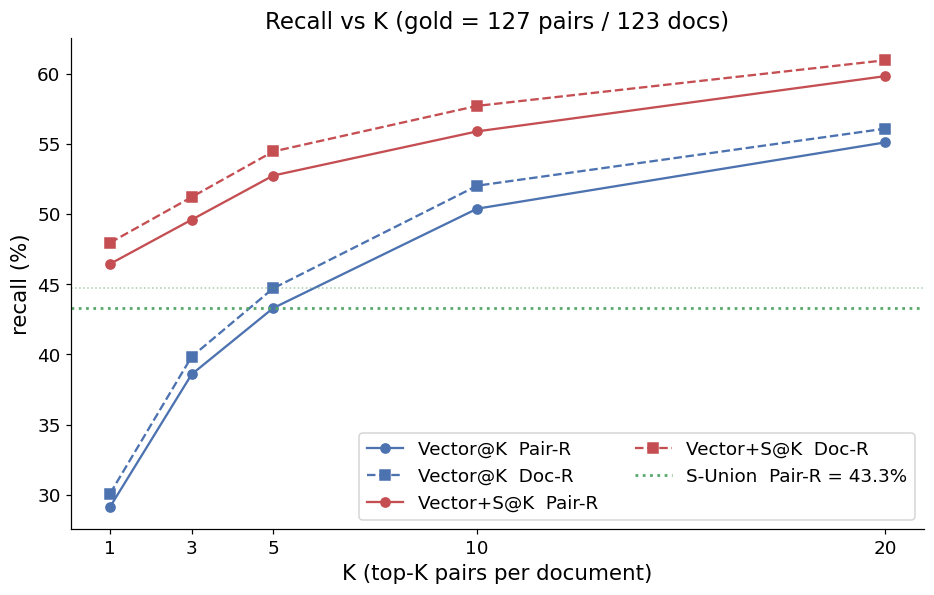

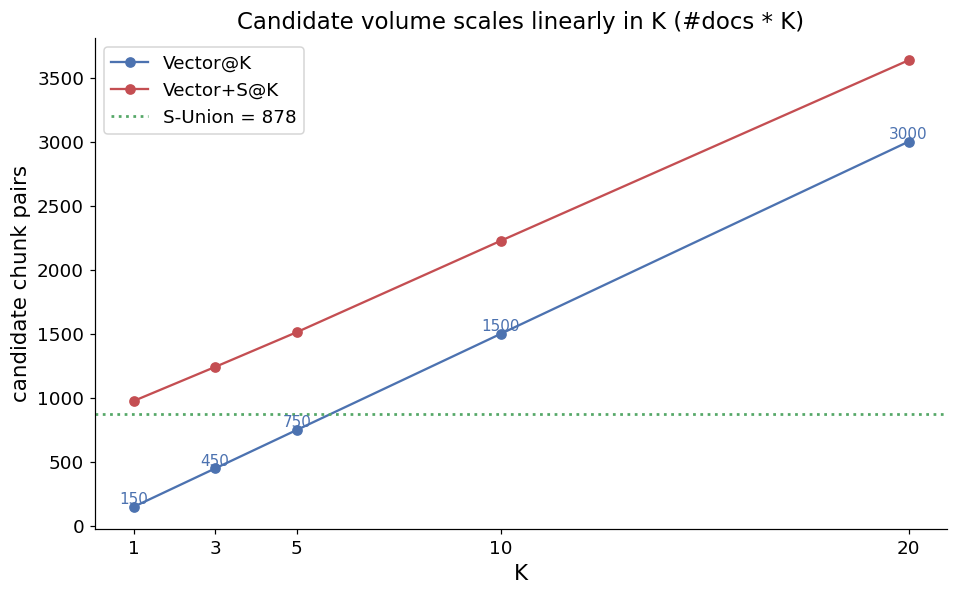

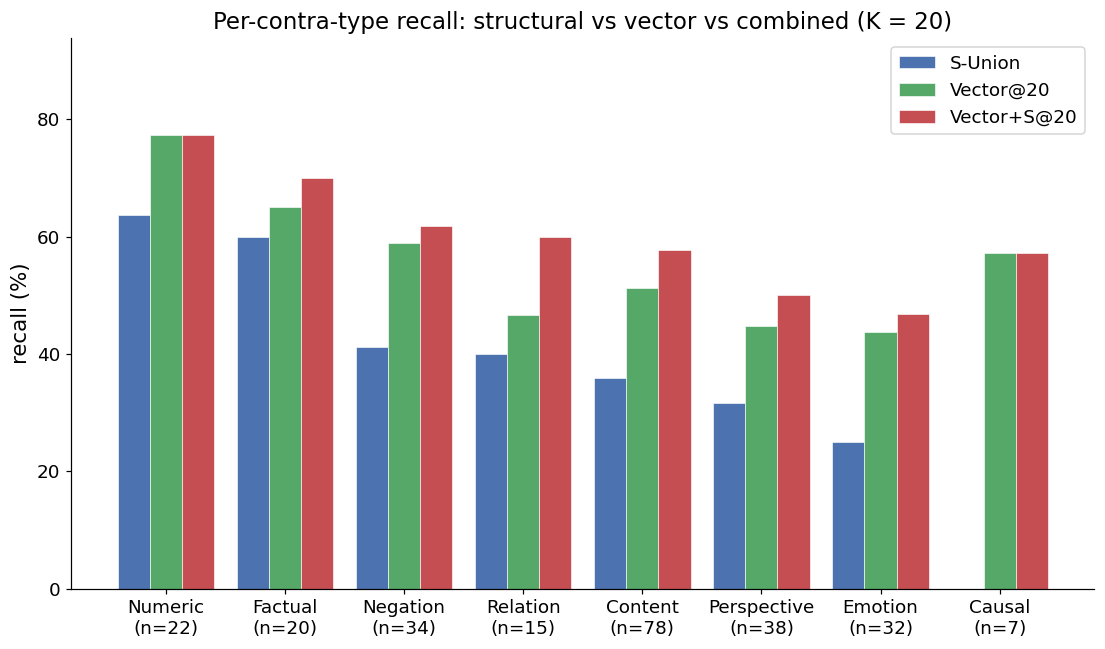

Saved 3 plots to D:\AT82.05-Claim-Contradiction-Over-Knowledge-Graphs\experiments\plots\05_vector_similarity


In [9]:
import matplotlib.pyplot as plt
import numpy as np

PLOT_DIR = Path("plots/05_vector_similarity")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 15,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

C_BLUE, C_RED, C_GREEN, C_PURPLE, C_YELLOW = "#4C72B0", "#C44E52", "#55A868", "#8172B2", "#CCB974"

# --- Plot 1: Pair-R + Doc-R + Precision vs K ---
vec_metrics = {k: metrics(vec_by_k[k], f"V@{k}") for k in K_VALUES}
union_metrics = {k: metrics(s_union | vec_by_k[k], f"V+S@{k}") for k in K_VALUES}
fig, ax = plt.subplots(figsize=(10, 5.8))
ax.plot(K_VALUES, [vec_metrics[k]["pair_r"] * 100 for k in K_VALUES], marker="o", color=C_BLUE, label="Vector@K  Pair-R")
ax.plot(K_VALUES, [vec_metrics[k]["doc_r"] * 100 for k in K_VALUES],  marker="s", color=C_BLUE, linestyle="--", label="Vector@K  Doc-R")
ax.plot(K_VALUES, [union_metrics[k]["pair_r"] * 100 for k in K_VALUES], marker="o", color=C_RED, label="Vector+S@K  Pair-R")
ax.plot(K_VALUES, [union_metrics[k]["doc_r"] * 100 for k in K_VALUES],  marker="s", color=C_RED, linestyle="--", label="Vector+S@K  Doc-R")
s_pair_r = metrics(s_union, "S-U")["pair_r"] * 100
s_doc_r  = metrics(s_union, "S-U")["doc_r"] * 100
ax.axhline(s_pair_r, color=C_GREEN, linestyle=":", linewidth=1.8, label=f"S-Union  Pair-R = {s_pair_r:.1f}%")
ax.axhline(s_doc_r,  color=C_GREEN, linestyle=":", linewidth=1.0, alpha=0.55)
ax.set_xticks(K_VALUES)
ax.set_xlabel("K (top-K pairs per document)")
ax.set_ylabel("recall (%)")
ax.set_title(f"Recall vs K (gold = {len(gold_pairs)} pairs / {n_gold_usable_docs} docs)")
ax.legend(loc="lower right", ncol=2)
fig.savefig(PLOT_DIR / "recall_vs_k.png")
plt.show()

# --- Plot 2: candidate volume vs K ---
fig, ax = plt.subplots(figsize=(10, 5.8))
ax.plot(K_VALUES, [len(vec_by_k[k]) for k in K_VALUES], marker="o", color=C_BLUE, label="Vector@K")
ax.plot(K_VALUES, [len(s_union | vec_by_k[k]) for k in K_VALUES], marker="o", color=C_RED, label="Vector+S@K")
ax.axhline(len(s_union), color=C_GREEN, linestyle=":", linewidth=1.8, label=f"S-Union = {len(s_union)}")
for k in K_VALUES:
    ax.text(k, len(vec_by_k[k]), f"{len(vec_by_k[k])}", ha="center", va="bottom", fontsize=10, color=C_BLUE)
ax.set_xticks(K_VALUES)
ax.set_xlabel("K")
ax.set_ylabel("candidate chunk pairs")
ax.set_title("Candidate volume scales linearly in K (#docs * K)")
ax.legend(loc="upper left")
fig.savefig(PLOT_DIR / "volume_vs_k.png")
plt.show()

# --- Plot 3: per-contra-type recall ---
type_order = ["Numeric", "Factual", "Negation", "Relation", "Content", "Perspective/View/Opinion", "Emotion/Mood/Feeling", "Causal"]
type_totals = {t: 0 for t in type_order}
for p in gold_pairs:
    for t in doc_types.get(p[0][0], []):
        if t in type_totals:
            type_totals[t] += 1

def _recall(pairs):
    caught = {t: 0 for t in type_order}
    for p in gold_pairs:
        if p in pairs:
            for t in doc_types.get(p[0][0], []):
                if t in caught:
                    caught[t] += 1
    return [caught[t] / max(type_totals[t], 1) * 100 for t in type_order]

su_rec  = _recall(s_union)
v_rec   = _recall(vec_by_k[PRIMARY_K])
vs_rec  = _recall(s_union | vec_by_k[PRIMARY_K])
x = np.arange(len(type_order))
w = 0.27
fig, ax = plt.subplots(figsize=(12, 6.5))
ax.bar(x - w, su_rec, w, label="S-Union",          color=C_BLUE,  edgecolor="white", linewidth=0.4)
ax.bar(x,     v_rec,  w, label=f"Vector@{PRIMARY_K}",   color=C_GREEN, edgecolor="white", linewidth=0.4)
ax.bar(x + w, vs_rec, w, label=f"Vector+S@{PRIMARY_K}", color=C_RED,   edgecolor="white", linewidth=0.4)
short = {
    "Perspective/View/Opinion": "Perspective",
    "Emotion/Mood/Feeling": "Emotion",
}
ax.set_xticks(x)
ax.set_xticklabels([f"{short.get(t, t)}\n(n={type_totals[t]})" for t in type_order], rotation=0)
ax.set_ylabel("recall (%)")
ax.set_title(f"Per-contra-type recall: structural vs vector vs combined (K = {PRIMARY_K})")
ymax = max(max(su_rec), max(v_rec), max(vs_rec))
ax.set_ylim(0, ymax * 1.15 + 5)
ax.legend(loc="upper right")
fig.savefig(PLOT_DIR / "per_type_recall.png")
plt.show()

print(f"Saved 3 plots to {PLOT_DIR.resolve()}")